# ***텍스트 데이터의 처리 응용-1***
## ***거대언어모델(LLM)의 동작 원리***

### ***데이터와 학습***
- 이차방정식 곡선의 점들을 데이터로 하여 이들을 학습시켜보겠습니다
- 여러개 (x, y) 점의 쌍을 보여주면 그 패턴을 학습하여 이차방정식 곡선의 점을 찍을 수 있음을 확인합니다
- 문장을 x, y와 같은 숫자의 시퀀스로 변환할 수 있음을 확인합니다
- 문장을 x, y와 같은 숫자의 시퀀스로 변환하여 벡터화하고(임베딩) 학습해봅니다

In [76]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


data_size = 100  # 10,100,500,1000 등 조절 가능

def get_data(data_size=100):

    np.random.seed(42)
    x = np.random.uniform(-10, 10, data_size).reshape(-1, 1).astype(np.float32)
    y = (2 * x**2 + 3 * x + 4).astype(np.float32)

    # 학습/테스트 분리
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    num_samples = 10
    print('==============학습데이터==================')
    for xi, yi in zip(x_train[:num_samples], y_train[:num_samples]):
        print(f"({xi}, {yi})")
    print('========================================')
    print()
    print('==============테스트데이터==================')
    for xi, yi in zip(x_test[:num_samples], y_test[:num_samples]):
        print(f"({xi}, {yi})")
    print('========================================')

    return x_train, x_test, y_train, y_test 

x_train, x_test, y_train, y_test  = get_data(100)

==============학습데이터==================
([8.437485], [171.69475])
([7.744255], [147.17975])
([-6.0065246], [58.137104])
([-9.312229], [149.49854])
([9.737739], [222.86032])
([-6.3319097], [65.19043])
([-7.559235], [95.60637])
([0.4546566], [5.7773952])
([4.1614513], [51.119705])
([-9.889558], [169.93803])

==============테스트데이터==================
([-8.728833], [130.19855])
([7.896547], [152.40054])
([5.4448953], [79.628456])
([3.2504456], [34.88213])
([-4.8244004], [36.076477])
([-1.1969501], [3.2745287])
([-4.157107], [26.091755])
([7.2620687], [131.26149])
([-9.58831], [159.10645])
([-2.5091977], [9.064552])


## ***학습 데이터 시각화***

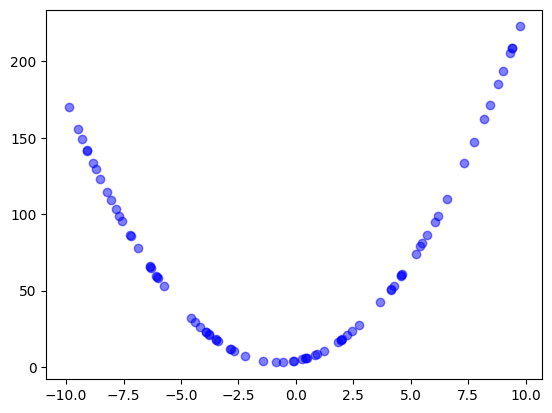

In [77]:
plt.scatter(x_train, y_train, color='blue', label='Train data', alpha=0.5)
plt.show()

### ***테스트 데이터 시각화***

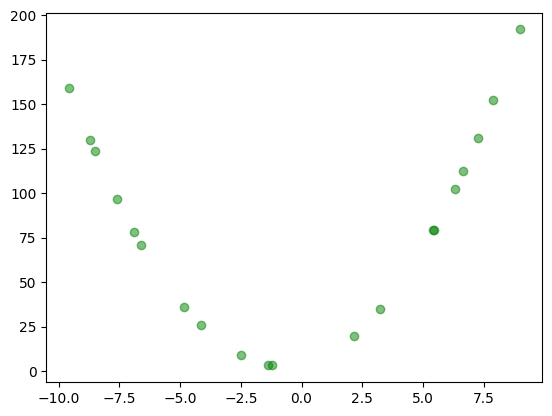

In [78]:
plt.scatter(x_test, y_test, color='green', label='Test data', alpha=0.5)
plt.show()

### ***데이터의 양과 반복 학습 횟수를 늘리면서 학습해보기***

==============학습데이터==================
([-9.0709915], [141.35281])
([8.895314], [188.93918])
([2.212401], [20.426638])
([-9.424347], [153.36359])
([8.296918], [166.56845])
([3.3511548], [36.513943])
([6.70605], [114.060356])
([5.2721157], [75.40675])
([-2.9329555], [12.40559])
([0.74791205], [7.362481])

==============테스트데이터==================
([-2.3821828], [8.203042])
([6.331989], [103.18413])
([-0.7464043], [2.8750257])
([-2.8780656], [11.932325])
([9.00124], [193.04836])
([9.389409], [208.49023])
([-0.74930567], [2.875001])
([7.3212776], [133.16605])
([-8.685827], [128.82971])
([0.37581244], [5.4099073])
Epoch 100/1000, Loss: 47.3635
Epoch 200/1000, Loss: 8.4119
Epoch 300/1000, Loss: 2.8807
Epoch 400/1000, Loss: 1.1411
Epoch 500/1000, Loss: 0.5088
Epoch 600/1000, Loss: 0.2779
Epoch 700/1000, Loss: 0.1796
Epoch 800/1000, Loss: 0.1316
Epoch 900/1000, Loss: 0.1144
Epoch 1000/1000, Loss: 0.1067


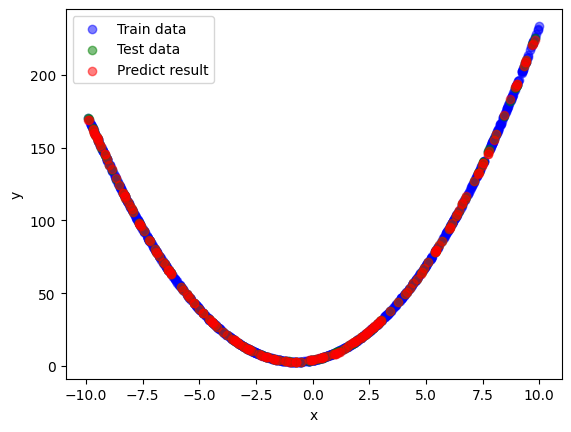

In [80]:
# 아래 두 항목을 늘리면서 테스트 해봅시다
date_size = 10 # 100, 1000, 10000
epochs = 10 # 100, 500, 1000

x_train, x_test, y_train, y_test = get_data(date_size)

# NumPy → Torch Tensor
x_train = torch.from_numpy(x_train)
y_train = torch.from_numpy(y_train)
x_test = torch.from_numpy(x_test)
y_test = torch.from_numpy(y_test)

class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

# 학습 루프
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    # 100 epoch마다 loss 출력
    if (epoch+1) % 100 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

# 테스트 예측
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test)


# 시각화
plt.scatter(x_train.numpy(), y_train.numpy(), color='blue', label='Train data', alpha=0.5)
plt.scatter(x_test.numpy(), y_test.numpy(), color='green', label='Test data', alpha=0.5)
plt.scatter(x_test.numpy(), y_pred_test.numpy(), color='red', label='Predict result', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## ***여기서 알수 있는 것***
- 데이터로 함수를 만들 수 있습니다
- 데이터의 양이 많아지면 좀더 정확한 함수를 만들 수 있습니다
- 적당히 반복 학습을 하면 좀더 정확한 함수를 만들 수 있습니다

## ***지금부터 진행할 내용***
- 우리의 단어를 숫자로 바꾸는 토크나이저를 만들어봅니다
- 그러면 이 숫자들도 학습될 수 있음을 이해합니다
- 입력 문장 -> 함수 -> 출력 문장(이어질 문장) 

### ***Vocab***
- 한글 문자, 영문자, 숫자, 문장부호를 숫자에 매핑시키는 vocab을 만듭니다
- 좀더 강조해서 학습하고 싶은 단어가 있으면 추가해봅니다

In [8]:
# 기본 한글 + 영어 + 숫자
hangul_start = ord("가")
hangul_end = ord("힣")
vocab = {chr(i): i for i in range(hangul_start, hangul_end+1)}
for c in "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.?! ":
    vocab[c] = len(vocab)
vocab["<unk>"] = len(vocab)

# 강조 단어 추가
custom_words = ["인공지능", "학습", "데이터"]
for w in custom_words:
    vocab[w] = len(vocab)

# 자모 범위 추가
jamo_ranges = [
    (ord('ㄱ'), ord('ㅣ')),  # 호환 자모 (ㄱ~ㅣ)
]

for start, end in jamo_ranges:
    for i in range(start, end + 1):
        vocab[chr(i)] = len(vocab)

In [9]:
vocab

{'가': 44032,
 '각': 44033,
 '갂': 44034,
 '갃': 44035,
 '간': 44036,
 '갅': 44037,
 '갆': 44038,
 '갇': 44039,
 '갈': 44040,
 '갉': 44041,
 '갊': 44042,
 '갋': 44043,
 '갌': 44044,
 '갍': 44045,
 '갎': 44046,
 '갏': 44047,
 '감': 44048,
 '갑': 44049,
 '값': 44050,
 '갓': 44051,
 '갔': 44052,
 '강': 44053,
 '갖': 44054,
 '갗': 44055,
 '갘': 44056,
 '같': 44057,
 '갚': 44058,
 '갛': 44059,
 '개': 44060,
 '객': 44061,
 '갞': 44062,
 '갟': 44063,
 '갠': 44064,
 '갡': 44065,
 '갢': 44066,
 '갣': 44067,
 '갤': 44068,
 '갥': 44069,
 '갦': 44070,
 '갧': 44071,
 '갨': 44072,
 '갩': 44073,
 '갪': 44074,
 '갫': 44075,
 '갬': 44076,
 '갭': 44077,
 '갮': 44078,
 '갯': 44079,
 '갰': 44080,
 '갱': 44081,
 '갲': 44082,
 '갳': 44083,
 '갴': 44084,
 '갵': 44085,
 '갶': 44086,
 '갷': 44087,
 '갸': 44088,
 '갹': 44089,
 '갺': 44090,
 '갻': 44091,
 '갼': 44092,
 '갽': 44093,
 '갾': 44094,
 '갿': 44095,
 '걀': 44096,
 '걁': 44097,
 '걂': 44098,
 '걃': 44099,
 '걄': 44100,
 '걅': 44101,
 '걆': 44102,
 '걇': 44103,
 '걈': 44104,
 '걉': 44105,
 '걊': 44106,
 '걋': 44107,
 '걌': 44108,

### ***Tokenizer***
- 우리의 문장을 vocab으로부터 longest match 방식으로 변환합니다
- 예를 들어 "인공지능은 어떻게 학습되는가?" 를 tokenizer와 vocab으로 변환하면 아래와 같습니다

In [ ]:
# "인공지능" 이라는 단어는 longest match에 의해 아래 "인공지능" 에 매칭됩니다
vocab['인공지능'], vocab['인'], vocab['공'],vocab['지'], vocab['능']

(11239, 51064, 44277, 51648, 45733)

In [15]:
def tokenize(text, vocab):
    tokens = []
    i = 0
    while i < len(text):
        match = None
        # 가장 긴 단어부터 탐색
        for j in range(len(text), i, -1):
            sub = text[i:j]
            if sub in vocab:
                match = sub
                break
        if match:
            tokens.append(match)
            i += len(match)
        else:
            tokens.append("<unk>")
            i += 1
    return tokens

In [16]:
text = "인공지능은 어떻게 학습되는가?"

# 토큰화
tokens = tokenize(text, vocab)

# 토큰 → 숫자(id)
token_ids = [vocab[t] for t in tokens]

print(tokens)
print(token_ids)

['인공지능', '은', ' ', '어', '떻', '게', ' ', '학습', '되', '는', '가', '?']
[11239, 51008, 11237, 50612, 46523, 44172, 11237, 11240, 46104, 45716, 44032, 11235]


## ***vocab과 tokenizer를 이용해 변환된 숫자를 학습시키기***
- 위에서 만든 vocab의 크기는 너무 커서 테스트 용도로 학습하기에는 너무 큽니다
- 아래와 같이 여러 테스트 문장을 적어 이를 베이스로 vocab을 재구성하여 학습합니다

In [18]:
sentences = [
    "나는 밥을 먹는다",
    "나는 학교에 간다",
    "나는 공부를 한다",
    "오늘 날씨가 좋다",
    "인공지능을 공부한다"
]

In [19]:
import torch
import torch.nn as nn

def tokenize(text):
    return text.split()

vocab = {}
for s in sentences:
    for w in tokenize(s):
        if w not in vocab:
            vocab[w] = len(vocab)

id_to_word = {i: w for w, i in vocab.items()}

vocab_size = len(vocab)
print("Vocab:", vocab)

Vocab: {'나는': 0, '밥을': 1, '먹는다': 2, '학교에': 3, '간다': 4, '공부를': 5, '한다': 6, '오늘': 7, '날씨가': 8, '좋다': 9, '인공지능을': 10, '공부한다': 11}


#### ***슬라이딩 윈도우 형태의 데이터 세트 생성***

In [20]:
X = []
y = []

for s in sentences:
    tokens = tokenize(s)
    ids = [vocab[t] for t in tokens]
    for i in range(len(ids)-1):
        X.append(ids[:i+1])
        y.append(ids[i+1])

print(X)
print(y)

[[0], [0, 1], [0], [0, 3], [0], [0, 5], [7], [7, 8], [10]]
[1, 2, 3, 4, 5, 6, 8, 9, 11]


#### ***패딩***
- 입력 크기를 맞추기 위해 0을 붙여주는 과정

In [21]:
max_len = max(len(x) for x in X)

def pad(seq):
    return seq + [0]*(max_len - len(seq))

X = [pad(x) for x in X]

print(X)
print(y)

[[0, 0], [0, 1], [0, 0], [0, 3], [0, 0], [0, 5], [7, 0], [7, 8], [10, 0]]
[1, 2, 3, 4, 5, 6, 8, 9, 11]


In [22]:
X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y)

embedding_dim = 16

model = nn.Sequential(
    nn.Embedding(vocab_size, embedding_dim),
    nn.Flatten(),
    nn.Linear(embedding_dim * max_len, 64),
    nn.ReLU(),
    nn.Linear(64, vocab_size)
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(500):
    pred = model(X_tensor)
    loss = loss_fn(pred, y_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

Epoch 100 Loss: 0.3665
Epoch 200 Loss: 0.3662
Epoch 300 Loss: 0.3662
Epoch 400 Loss: 0.3664
Epoch 500 Loss: 0.3662


In [23]:
def generate(start_word, steps=3):
    tokens = [vocab[start_word]]
    
    for _ in range(steps):
        # 항상 max_len 길이로 padding
        x = tokens[-max_len:]  # 최근 max_len만 사용
        x = pad(x)
        x = torch.tensor([x])
        
        pred = model(x)
        next_id = pred.argmax().item()
        tokens.append(next_id)
    
    return " ".join(id_to_word[t] for t in tokens)


print("Generated:", generate("나는"))
print("Generated:", generate("인공지능을"))

Generated: 나는 밥을 먹는다 공부한다
Generated: 인공지능을 공부한다 공부한다 좋다


## ***단어가 벡터로 변환되는 과정 알아보기***
- 위의 학습 과정을 확인해보면 우리의 단어를 8차원 벡터로 변환하여 학습합니다
- 이 벡터또한 학습되면서 변화합니다
- 유사도가 높은 단어들은 비슷한 벡터로 변화하는 것입니다
- 먼저 학습 초기의 벡터 상태를 확인해봅니다

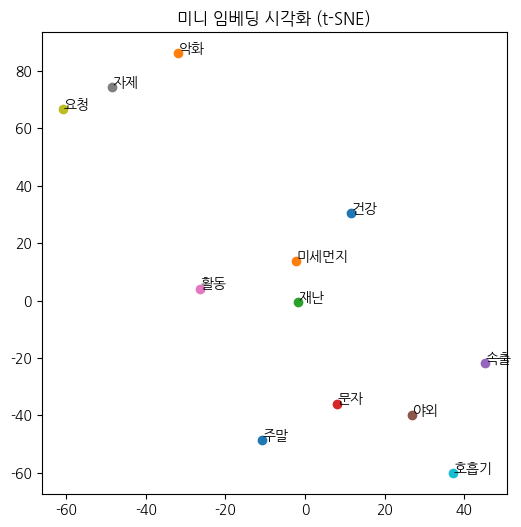

==== 코사인 유사도 행렬 ====
[[ 1.   -0.43  0.25  0.36  0.19  0.21  0.06 -0.13 -0.42  0.41  0.34 -0.15]
 [-0.43  1.    0.15 -0.61 -0.34 -0.19  0.32  0.05  0.4   0.16  0.38 -0.21]
 [ 0.25  0.15  1.   -0.03  0.44 -0.01  0.24 -0.21 -0.58  0.31  0.17  0.27]
 [ 0.36 -0.61 -0.03  1.    0.31  0.41 -0.66 -0.32 -0.34  0.29 -0.42 -0.21]
 [ 0.19 -0.34  0.44  0.31  1.    0.51 -0.38  0.02 -0.55  0.49 -0.25  0.27]
 [ 0.21 -0.19 -0.01  0.41  0.51  1.   -0.31  0.36  0.25  0.52 -0.6   0.15]
 [ 0.06  0.32  0.24 -0.66 -0.38 -0.31  1.    0.07  0.17 -0.12  0.23 -0.06]
 [-0.13  0.05 -0.21 -0.32  0.02  0.36  0.07  1.    0.61 -0.38 -0.22  0.5 ]
 [-0.42  0.4  -0.58 -0.34 -0.55  0.25  0.17  0.61  1.   -0.29 -0.28  0.06]
 [ 0.41  0.16  0.31  0.29  0.49  0.52 -0.12 -0.38 -0.29  1.    0.09 -0.45]
 [ 0.34  0.38  0.17 -0.42 -0.25 -0.6   0.23 -0.22 -0.28  0.09  1.   -0.28]
 [-0.15 -0.21  0.27 -0.21  0.27  0.15 -0.06  0.5   0.06 -0.45 -0.28  1.  ]]


In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 간단한 vocab
vocab = ['주말', '미세먼지', '재난', '문자', '속출', '야외', '활동', '자제', '요청', '호흡기', '건강', '악화']
vocab_size = len(vocab)
word_to_id = {w:i for i,w in enumerate(vocab)}
id_to_word = {i:w for w,i in word_to_id.items()}

# 미니 임베딩 층
embedding_dim = 8
embedding_layer = nn.Embedding(vocab_size, embedding_dim)

# 랜덤 초기화 상태의 임베딩 확인 가능
embeddings = embedding_layer(torch.arange(vocab_size)).detach().numpy()

# t-SNE로 2차원 시각화
tsne = TSNE(n_components=2, perplexity=2, random_state=42)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(6,6))
for i, w in enumerate(vocab):
    x, y = emb_2d[i]
    plt.scatter(x, y)
    plt.text(x+0.1, y+0.1, w)
plt.title("미니 임베딩 시각화 (t-SNE)")
plt.show()

# 코사인 유사도 계산
cos_sim = cosine_similarity(embeddings)
print("==== 코사인 유사도 행렬 ====")
print(np.round(cos_sim, 2))

학습 시작...
Epoch 50, Loss: 0.1450
Epoch 100, Loss: 0.0219
Epoch 150, Loss: 0.0083
Epoch 200, Loss: 0.0042
학습 완료

==== 학습 후 임베딩 벡터 ====
주말: [ 3.566  1.778 -2.17  -0.213 -2.566 -2.127  2.027 -0.771]
미세먼지: [-0.451 -0.146 -1.9    2.377  2.541 -0.347  0.29  -0.539]
재난: [-1.213  0.67   1.996 -3.584 -1.458  0.761  2.966 -1.973]
문자: [ 0.336 -1.046  0.765 -1.741  1.884  3.615 -2.67  -1.184]
속출: [-0.649  1.185 -2.454  0.347 -1.069 -1.696 -0.009 -1.525]
야외: [-0.463  1.039 -0.827  2.011 -0.37  -2.407  1.294 -1.26 ]
활동: [-2.413  0.199  0.861  1.479  1.982 -1.467 -0.804 -2.575]
자제: [-1.989  2.004  2.306  0.415  0.874  1.024  0.677 -2.777]
요청: [-1.137  1.697  0.462 -1.222 -0.937  0.618 -0.468 -0.075]
호흡기: [-1.88  -1.154  0.087  0.078  1.194  1.03  -3.365  0.009]
건강: [ 0.147 -2.457  0.774 -1.401 -1.086  1.923 -0.559 -2.406]
악화: [-1.302 -0.922 -2.039 -0.561 -0.442  0.965  0.363 -0.062]

==== 코사인 유사도 행렬 ====
[[ 1.   -0.12  0.08 -0.57  0.55  0.48 -0.42 -0.33 -0.1  -0.81 -0.22 -0.11]
 [-0.12  1.   -0.59 -0.

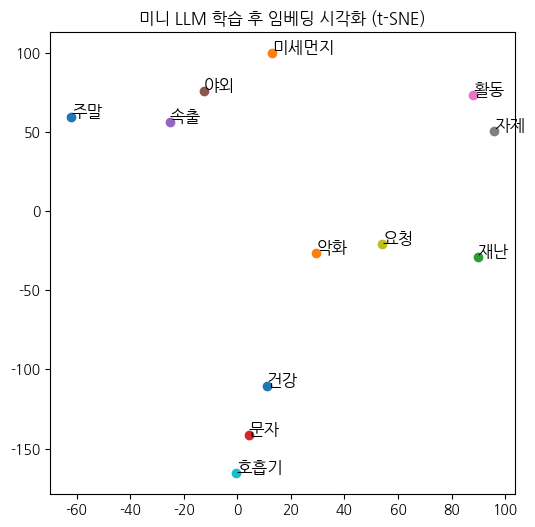

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

# vocab 정의
vocab = ['주말', '미세먼지', '재난', '문자', '속출', '야외', '활동', '자제', '요청', '호흡기', '건강', '악화']
vocab_size = len(vocab)
word_to_id = {w:i for i,w in enumerate(vocab)}
id_to_word = {i:w for i,w in word_to_id.items()}

# 미니 시퀀스 데이터
seqs = [
    ["주말", "미세먼지", "재난", "문자", "속출"],
    ["미세먼지", "호흡기", "건강", "악화"],
    ["야외", "활동", "자제", "요청"]
]

X, Y = [], []
for seq in seqs:
    ids = [word_to_id[w] for w in seq]
    for i in range(len(ids)-1):
        X.append(ids[:i+1])
        Y.append(ids[i+1])

X_tensor = [torch.tensor(xi).unsqueeze(0) for xi in X]
Y_tensor = [torch.tensor(yi) for yi in Y]

# 미니 LLM 정의
embedding_dim = 8
hidden_dim = 16

class MiniLLM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        x = self.embedding(x)
        x = x.mean(dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = MiniLLM(vocab_size, embedding_dim, hidden_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 학습
print("학습 시작...")
for epoch in range(200):
    total_loss = 0
    for xi, yi in zip(X_tensor, Y_tensor):
        optimizer.zero_grad()
        out = model(xi)
        loss = criterion(out, yi.unsqueeze(0))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
print("학습 완료")

# 학습 후 임베딩 벡터 확인
embeddings = model.embedding.weight.detach().numpy()
print("\n==== 학습 후 임베딩 벡터 ====")
for i, w in enumerate(vocab):
    print(f"{w}: {np.round(embeddings[i], 3)}")

# 코사인 유사도
cos_sim = cosine_similarity(embeddings)
print("\n==== 코사인 유사도 행렬 ====")
print(np.round(cos_sim, 2))

# t-SNE 시각화
tsne = TSNE(n_components=2, perplexity=2, random_state=42)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(6,6))
for i, w in enumerate(vocab):
    x, y = emb_2d[i]
    plt.scatter(x, y)
    plt.text(x+0.05, y+0.05, w, fontsize=12)
plt.title("미니 LLM 학습 후 임베딩 시각화 (t-SNE)")
plt.show()